# Notebook for constructing age models for Michipicoten Island Formation

In [ ]:
using Pkg
Pkg.activate("../")
using Chron
using Plots, DelimitedFiles
using DataFrames, CSV
using Statistics, StatsBase

include("MCR_age_models.jl")

plot_posterior_paths (generic function with 1 method)

## Michipicoten Island Formation

- We define the bottom of the section to be the base of the Quebect Harbor andesite which is above the West Sand Bay tuff
- We define the top of the section to be the Davieaux Island rhyolite

In [2]:
Michipicoten_Name = ("West Sand Bay Member tuff", "Davieaux Island rhyolite") # Et cetera
Michipicoten_Age           = [ 1084.35, 1083.52] # Measured ages
Michipicoten_Age_sigma     = [ 0.2/2,   0.23/2] # Measured 1-σ uncertainties
Michipicoten_Height        = [ 0,     1006] # Depths below surface should be negative
Michipicoten_Age_Sidedness = [0, 0] # Sidedness (zeros by default: geochron constraints are two-sided). Use -1 for a maximum age and +1 for a minimum age, 0 for two-sided

Michipicoten_Path = "../../data/age_models_output/Michipicoten" # Where do you want output files to be stored

# construct the section (ChronAgeData object)
Michipicoten_section = make_ChronAgeData(Michipicoten_Name, Michipicoten_Age, Michipicoten_Age_sigma, Michipicoten_Height, Michipicoten_Age_Sidedness, Michipicoten_Path, Age_Unit="Ma", Height_Unit="m")

ChronAgeData{2}(("West Sand Bay Member tuff", "Davieaux Island rhyolite"), [0.0, 1006.0], [0.01, 0.01], [1084.35, 1083.52], [0.1, 0.115], [NaN, NaN], [NaN, NaN], [NaN, NaN], [NaN, NaN], [0.0, 0.0], [0.0, 0.0], [#undef, #undef], (:Chronometer, :Chronometer), [NaN NaN; NaN NaN; … ; NaN NaN; NaN NaN], "../../data/age_models_output/Michipicoten", 2, "Ma", "m", :cdf)

In [3]:
Michipicoten_age_model_config, Michipicoten_age_model_mdl, Michipicoten_age_model_agedist, Michipicoten_age_model_lldist = run_age_model(Michipicoten_section, 2, 0.2, 5000, save_results=false, plot_results=false)

┌ Info: Generating stratigraphic age-depth model...
└ @ Chron /Users/yimingzhang/.julia/packages/Chron/zKIt8/src/StratMetropolis.jl:28
┌ Info: Burn-in: 3530000 steps
└ @ Chron /Users/yimingzhang/.julia/packages/Chron/zKIt8/src/StratMetropolis.jl:626
Burn-in... 100%|█████████████████████████████████████████| Time: 0:00:00
┌ Info: Collecting sieved stationary distribution: 3530000 steps
└ @ Chron /Users/yimingzhang/.julia/packages/Chron/zKIt8/src/StratMetropolis.jl:689
Collecting... 100%|██████████████████████████████████████| Time: 0:00:00


(StratAgeModelConfiguration(2.0, 3530000, 5000, 706, 0.2), StratAgeModel([0.0, 2.0, 4.0, 6.0, 8.0, 10.0, 12.0, 14.0, 16.0, 18.0  …  988.0, 990.0, 992.0, 994.0, 996.0, 998.0, 1000.0, 1002.0, 1004.0, 1006.0], [1084.3616259460764, 1084.3600948765343, 1084.3585576360022, 1084.3566239887152, 1084.3549992245353, 1084.3536655246244, 1084.3518408459302, 1084.350127955965, 1084.3482999139794, 1084.3463403333565  …  1083.5230802089247, 1083.5212554477764, 1083.5192762262532, 1083.5179182898485, 1083.516275181952, 1083.514794230511, 1083.5131346612181, 1083.5115192864446, 1083.5101717854454, 1083.5084701996936], [0.08323601772152406, 0.08422267412234945, 0.08546317014626652, 0.0870350649983376, 0.08849116907788349, 0.08920545129140195, 0.09043674772457634, 0.09195689188330895, 0.09360153329662801, 0.09530183126252999  …  0.09955300878175147, 0.09837188360858617, 0.09695506051467086, 0.09634415261329744, 0.09517302252631472, 0.09408563592383319, 0.09308863879571799, 0.09185557513767366, 0.09108444

### posterior summary age model

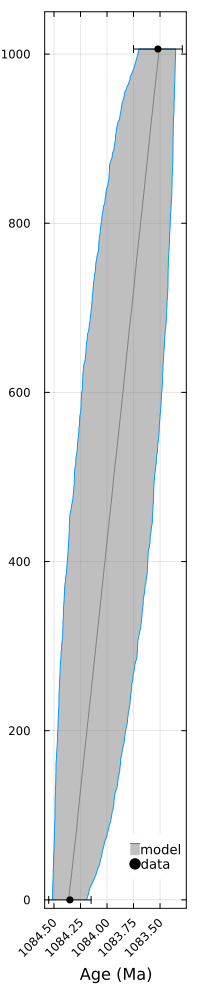

In [4]:
Michipicoten_age_model = plot_age_model(Michipicoten_section, Michipicoten_age_model_mdl, save_figure=false)
plot!(ylim=(-10, 1050))
# show xticks 
yticks!([0, 200, 400, 600, 800, 1000])
savefig(Michipicoten_age_model, Michipicoten_section.Path*"_AgeDepthModel.pdf")
display(Michipicoten_age_model)

### example posterior accumulation models

In [5]:
plot_accumulation_model(Michipicoten_section, Michipicoten_age_model_config, Michipicoten_age_model_mdl, Michipicoten_age_model_agedist, save_figure=false)

ArgumentError: ArgumentError: invalid Array dimensions

### example posterior age models

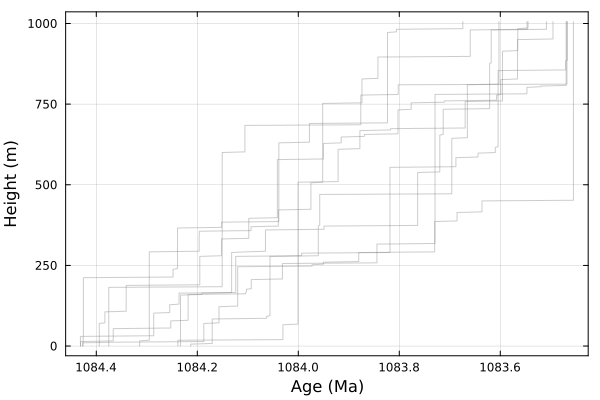

In [6]:
plot_posterior_paths(Michipicoten_section, Michipicoten_age_model_agedist, Michipicoten_age_model_mdl)

## save the age models to a file

In [7]:
Michipicoten_age_model_agedist

504×5000 Matrix{Float64}:
 1084.26  1084.41  1084.43  1084.29  …  1084.3  1084.26  1084.5   1084.32
 1084.26  1084.41  1084.43  1084.29     1084.3  1084.26  1084.5   1084.32
 1084.26  1084.41  1084.43  1084.29     1084.3  1084.26  1084.5   1084.32
 1084.26  1084.41  1084.43  1084.29     1084.3  1084.22  1084.5   1084.32
 1084.26  1084.41  1084.43  1084.29     1084.3  1084.22  1084.5   1084.32
 1084.26  1084.41  1084.43  1084.29  …  1084.3  1084.22  1084.5   1084.32
 1084.26  1084.41  1084.43  1084.29     1084.3  1084.22  1084.5   1084.32
 1084.26  1084.41  1084.43  1084.29     1084.3  1084.22  1084.5   1084.32
 1084.26  1084.41  1084.43  1084.29     1084.3  1084.22  1084.5   1084.32
 1084.26  1084.41  1084.43  1084.29     1084.3  1084.22  1084.5   1084.32
    ⋮                                ⋱                            
 1083.52  1083.57  1083.79  1083.51  …  1083.5  1083.55  1083.62  1083.4
 1083.52  1083.57  1083.79  1083.51     1083.5  1083.55  1083.62  1083.4
 1083.52  1083.57  10

In [8]:
# use the mdl.height as index, agedist as the data
Michipicoten_age_models_df = DataFrame(hcat(Michipicoten_age_model_mdl.Height, Michipicoten_age_model_agedist), :auto)
# rename the first three columns to be site, height
rename!(Michipicoten_age_models_df, Dict(:x1 => "height"))
Michipicoten_age_models_df

Row,height,x2,x3,x4,x5,x6,x7,x8,x9,x10,x11,x12,x13,x14,x15,x16,x17,x18,x19,x20,x21,x22,x23,x24,x25,x26,x27,x28,x29,x30,x31,x32,x33,x34,x35,x36,x37,x38,x39,x40,x41,x42,x43,x44,x45,x46,x47,x48,x49,x50,x51,x52,x53,x54,x55,x56,x57,x58,x59,x60,x61,x62,x63,x64,x65,x66,x67,x68,x69,x70,x71,x72,x73,x74,x75,x76,x77,x78,x79,x80,x81,x82,x83,x84,x85,x86,x87,x88,x89,x90,x91,x92,x93,x94,x95,x96,x97,x98,x99,x100,⋯
,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,⋯
1,0.0,1084.26,1084.41,1084.43,1084.29,1084.49,1084.27,1084.45,1084.47,1084.41,1084.42,1084.4,1084.45,1084.4,1084.48,1084.47,1084.43,1084.14,1084.31,1084.38,1084.23,1084.45,1084.39,1084.41,1084.35,1084.36,1084.22,1084.4,1084.33,1084.39,1084.49,1084.28,1084.37,1084.4,1084.35,1084.2,1084.42,1084.2,1084.44,1084.46,1084.4,1084.39,1084.45,1084.26,1084.4,1084.26,1084.41,1084.35,1084.45,1084.29,1084.39,1084.4,1084.19,1084.27,1084.33,1084.38,1084.53,1084.28,1084.38,1084.29,1084.43,1084.54,1084.42,1084.38,1084.49,1084.31,1084.35,1084.3,1084.47,1084.41,1084.35,1084.37,1084.45,1084.43,1084.42,1084.37,1084.4,1084.46,1084.26,1084.37,1084.35,1084.39,1084.37,1084.35,1084.42,1084.39,1084.41,1084.51,1084.4,1084.42,1084.47,1084.28,1084.47,1084.42,1084.18,1084.45,1084.44,1084.28,1084.31,1084.52,⋯
2,2.0,1084.26,1084.41,1084.43,1084.29,1084.49,1084.27,1084.31,1084.47,1084.41,1084.42,1084.4,1084.45,1084.4,1084.48,1084.47,1084.43,1084.14,1084.31,1084.38,1084.23,1084.45,1084.39,1084.41,1084.35,1084.36,1084.22,1084.4,1084.33,1084.39,1084.49,1084.28,1084.37,1084.4,1084.35,1084.2,1084.42,1084.2,1084.44,1084.46,1084.4,1084.39,1084.45,1084.26,1084.4,1084.26,1084.41,1084.35,1084.45,1084.29,1084.39,1084.4,1084.19,1084.27,1084.33,1084.38,1084.53,1084.28,1084.38,1084.29,1084.42,1084.54,1084.42,1084.38,1084.49,1084.31,1084.35,1084.3,1084.47,1084.41,1084.35,1084.37,1084.45,1084.43,1084.42,1084.37,1084.4,1084.46,1084.26,1084.37,1084.35,1084.39,1084.37,1084.35,1084.42,1084.39,1084.41,1084.51,1084.4,1084.42,1084.47,1084.28,1084.47,1084.42,1084.18,1084.45,1084.44,1084.28,1084.31,1084.52,⋯
3,4.0,1084.26,1084.41,1084.43,1084.29,1084.49,1084.27,1084.31,1084.47,1084.41,1084.42,1084.4,1084.45,1084.4,1084.48,1084.47,1084.43,1084.14,1084.31,1084.38,1084.23,1084.45,1084.39,1084.41,1084.35,1084.36,1084.22,1084.4,1084.33,1084.39,1084.49,1084.28,1084.37,1084.4,1084.35,1084.2,1084.42,1084.2,1084.44,1084.46,1084.4,1084.39,1084.45,1084.14,1084.4,1084.26,1084.41,1084.35,1084.45,1084.29,1084.39,1084.4,1084.19,1084.27,1084.33,1084.38,1084.53,1084.28,1084.38,1084.29,1084.42,1084.54,1084.42,1084.38,1084.49,1084.31,1084.35,1084.3,1084.47,1084.41,1084.35,1084.37,1084.45,1084.43,1084.42,1084.37,1084.4,1084.46,1084.26,1084.37,1084.35,1084.39,1084.37,1084.35,1084.42,1084.39,1084.41,1084.51,1084.4,1084.25,1084.47,1084.28,1084.44,1084.42,1084.18,1084.45,1084.44,1084.28,1084.31,1084.52,⋯
4,6.0,1084.26,1084.41,1084.43,1084.29,1084.49,1084.27,1084.31,1084.47,1084.41,1084.42,1084.4,1084.45,1084.4,1084.48,1084.47,1084.43,1084.14,1084.31,1084.38,1084.23,1084.45,1084.39,1084.41,1084.35,1084.36,1084.22,1084.4,1084.33,1084.39,1084.49,1084.28,1084.37,1084.4,1084.35,1084.2,1084.42,1084.2,1084.44,1084.4,1084.4,1084.39,1084.45,1084.14,1084.4,1084.26,1084.41,1084.35,1084.38,1084.29,1084.39,1084.4,1084.19,1084.27,1084.33,108

In [9]:
# write the DataFrame to a csv file
CSV.write(Michipicoten_section.Path*"_posterior_ages.csv", Michipicoten_age_models_df)

"../../data/age_models_output/Michipicoten_posterior_ages.csv"